In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("final_dataset.csv")

df.head()

,DateTime,City,AQI,PM2.5,PM10,CO,NO2,SO2,O3,Temperature,Humidity,Wind_Speed,Pressure
0,2026-04-01 00:00:00,Delhi,2,16.38,31.18,456.06,22.03,2.44,22.77,19.6,82,2.7,1010.2
1,2026-04-01 01:00:00,Delhi,2,16.44,30.58,458.14,20.47,1.85,20.91,19.8,79,2.6,1010.5
2,2026-04-01 02:00:00,Delhi,2,16.73,30.39,458.96,18.92,1.48,19.60,21.3,70,2.8,1011.1
3,2026-04-01 03:00:00,Delhi,2,17.18,30.51,455.28,17.35,1.26,18.95,23.8,60,1.5,1011.7
4,2026-04-01 04:00:00,Delhi,2,17.77,31.11,453.55,16.18,1.17,18.07,26.9,48,0.9,1012.3


In [4]:
df["DateTime"] = pd.to_datetime(df["DateTime"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DateTime     3024 non-null   datetime64[ns]
 1   City         3024 non-null   object        
 2   AQI          3024 non-null   int64         
 3   PM2.5        3024 non-null   float64       
 4   PM10         3024 non-null   float64       
 5   CO           3024 non-null   float64       
 6   NO2          3024 non-null   float64       
 7   SO2          3024 non-null   float64       
 8   O3           3024 non-null   float64       
 9   Temperature  3024 non-null   float64       
 10  Humidity     3024 non-null   int64         
 11  Wind_Speed   3024 non-null   float64       
 12  Pressure     3024 non-null   float64       
dtypes: datetime64[ns](1), float64(9), int64(2), object(1)
memory usage: 307.3+ KB


In [5]:
df = df.sort_values(by=["City", "DateTime"])
df.head()

,DateTime,City,AQI,PM2.5,PM10,CO,NO2,SO2,O3,Temperature,Humidity,Wind_Speed,Pressure
1728,2026-04-01 00:00:00,Bangalore,3,28.60,35.99,327.22,11.27,6.68,64.70,20.7,91,8.6,1012.8
1729,2026-04-01 01:00:00,Bangalore,3,28.70,35.90,332.78,10.67,6.01,59.96,20.9,85,8.9,1013.3
1730,2026-04-01 02:00:00,Bangalore,3,28.72,35.80,329.01,9.63,5.59,56.63,22.0,76,7.2,1013.6
1731,2026-04-01 03:00:00,Bangalore,3,28.71,35.71,320.08,8.61,5.24,53.86,24.9,58,5.8,1013.6
1732,2026-04-01 04:00:00,Bangalore,3,28.75,35.66,312.57,7.89,4.68,51.41,28.0,36,6.6,1013.8


In [6]:
print(len(df))

3024


In [7]:
df = df.drop_duplicates()

print("Remaining rows:", len(df))

Remaining rows: 3024


In [8]:
df.isnull().sum()

DateTime       0
City           0
AQI            0
PM2.5          0
PM10           0
CO             0
NO2            0
SO2            0
O3             0
Temperature    0
Humidity       0
Wind_Speed     0
Pressure       0
dtype: int64

In [9]:
df["Day"] = df["DateTime"].dt.day_name()
df["Hour"] = df["DateTime"].dt.hour

df.head()

,DateTime,City,AQI,PM2.5,PM10,CO,NO2,SO2,O3,Temperature,Humidity,Wind_Speed,Pressure,Day,Hour
1728,2026-04-01 00:00:00,Bangalore,3,28.60,35.99,327.22,11.27,6.68,64.70,20.7,91,8.6,1012.8,Wednesday,0
1729,2026-04-01 01:00:00,Bangalore,3,28.70,35.90,332.78,10.67,6.01,59.96,20.9,85,8.9,1013.3,Wednesday,1
1730,2026-04-01 02:00:00,Bangalore,3,28.72,35.80,329.01,9.63,5.59,56.63,22.0,76,7.2,1013.6,Wednesday,2
1731,2026-04-01 03:00:00,Bangalore,3,28.71,35.71,320.08,8.61,5.24,53.86,24.9,58,5.8,1013.6,Wednesday,3
1732,2026-04-01 04:00:00,Bangalore,3,28.75,35.66,312.57,7.89,4.68,51.41,28.0,36,6.6,1013.8,Wednesday,4


In [10]:
def time_category(h):
    if h < 12:
        return "Morning"
    elif h < 17:
        return "Afternoon"
    elif h < 21:
        return "Evening"
    else:
        return "Night"

df["Time_Category"] = df["Hour"].apply(time_category)

df.head()

,DateTime,City,AQI,PM2.5,PM10,CO,NO2,SO2,O3,Temperature,Humidity,Wind_Speed,Pressure,Day,Hour,Time_Category
1728,2026-04-01 00:00:00,Bangalore,3,28.60,35.99,327.22,11.27,6.68,64.70,20.7,91,8.6,1012.8,Wednesday,0,Morning
1729,2026-04-01 01:00:00,Bangalore,3,28.70,35.90,332.78,10.67,6.01,59.96,20.9,85,8.9,1013.3,Wednesday,1,Morning
1730,2026-04-01 02:00:00,Bangalore,3,28.72,35.80,329.01,9.63,5.59,56.63,22.0,76,7.2,1013.6,Wednesday,2,Morning
1731,2026-04-01 03:00:00,Bangalore,3,28.71,35.71,320.08,8.61,5.24,53.86,24.9,58,5.8,1013.6,Wednesday,3,Morning
1732,2026-04-01 04:00:00,Bangalore,3,28.75,35.66,312.57,7.89,4.68,51.41,28.0,36,6.6,1013.8,Wednesday,4,Morning


In [11]:
df.to_csv("cleaned_dataset.csv", index=False)

print("✅ Cleaned dataset saved")

✅ Cleaned dataset saved


In [12]:
df = df[df["AQI"] <= 5]

In [13]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

df.head()

,datetime,city,aqi,pm2.5,pm10,co,no2,so2,o3,temperature,humidity,wind_speed,pressure,day,hour,time_category
1728,2026-04-01 00:00:00,Bangalore,3,28.60,35.99,327.22,11.27,6.68,64.70,20.7,91,8.6,1012.8,Wednesday,0,Morning
1729,2026-04-01 01:00:00,Bangalore,3,28.70,35.90,332.78,10.67,6.01,59.96,20.9,85,8.9,1013.3,Wednesday,1,Morning
1730,2026-04-01 02:00:00,Bangalore,3,28.72,35.80,329.01,9.63,5.59,56.63,22.0,76,7.2,1013.6,Wednesday,2,Morning
1731,2026-04-01 03:00:00,Bangalore,3,28.71,35.71,320.08,8.61,5.24,53.86,24.9,58,5.8,1013.6,Wednesday,3,Morning
1732,2026-04-01 04:00:00,Bangalore,3,28.75,35.66,312.57,7.89,4.68,51.41,28.0,36,6.6,1013.8,Wednesday,4,Morning


Column names were standardized for consistency and ease of analysis


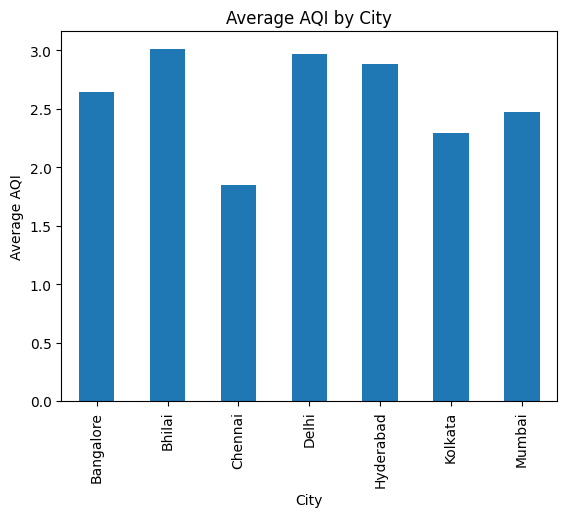

In [19]:
import matplotlib.pyplot as plt
df.groupby("city")["aqi"].mean().plot(kind="bar")

plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.show()

TypeError: string indices must be integers, not 'str'